In [190]:
import numpy as np
import spin_hamiltonian as spin
#import spin_hamiltonian_funcs as spinf
from scipy.spatial.transform import Rotation
import matplotlib.pyplot as plt


In [191]:
#spin Operators:
Espin = 1/2
Ispin = 1/2
IEr = 7/2


In [192]:
#electronic Zeeman interaction:

#g tensor ground state
g_G = np.matrix([[0.85,0,0],[0,0.85,0],[0,0,-6.08]])
#g tensor Excited state
g_E = np.matrix([[1.7,0,0],[0,1.7,0],[0,0,2.51]])



#tensor rotation
rot_g_G = spin.tensorRotation(g_G,[0,0,0])
rot_g_E = spin.tensorRotation(g_E,[0,0,0])



In [193]:
#Hyperfine interaction

#A tensor ground state
A_G = np.matrix([[2.99792458e10*0.0225*6.626e-34,0,0],[0,2.99792458e10*0.0225*6.626e-34,0],[0,0,-2.99792458e10*0.1608*6.626e-34]])
#A tensor Excited state
A_E = np.matrix([[ 6.626e-34*3.37e9,0,0],[0, 6.626e-34*3.37e9,0],[0,0,6.626e-34*4.86e9]])


#rotated tensors
rot_A_G = spin.tensorRotation(A_G,[0,0,0])
rot_A_E = spin.tensorRotation(A_E,[0,0,0])



In [194]:
ground = spin.cSpinHamiltonian(Espin,Ispin)
excited = spin.cSpinHamiltonian(Espin,Ispin)


ground.setgE(rot_g_G)
excited.setgE(rot_g_G)

ground.hyperfineInteraction(rot_A_G)
excited.hyperfineInteraction(rot_A_E)
pass



In [195]:
#Erbium
erbium = spin.cSpinHamiltonian(Espin,IEr)

A_Er = np.matrix([[139,0,0],[0,13,0],[0,0,-1604]])*spin.h*1E6 #from Jevon's group
ang_A_Er = np.array([262.2,94.07,81.9])*np.pi/180

rot_A_Er = spin.tensorRotation(A_Er,ang_A_Er,str='ZXZ')

print("A: ",rot_A_Er/(spin.h*1E6))

Q = np.matrix([[6,0,0],[0,36.1,0],[0,0,-42.1]])*spin.h*1E6 #from Jevon's group
ang_Er = np.array([142.81,77.5,16.8])*np.pi/180

Q = spin.tensorRotation(Q,ang_Er,str='ZXZ')


g_Er = np.matrix([[0.99,0,0],[0,1.695,0],[0,0,15.05]])#*spin.h*1E6 #from Jevon's group
ang_g_Er = np.array([261.98,100.16,97.25])*np.pi/180

rot_g_Er = spin.tensorRotation(g_Er,ang_g_Er,str='ZXZ')
#rot_g_Er = np.matrix([[14.75,-2.02,2.62],[-2.02,1.89,-0.93],[2.62,-0.93,0.05]]) #from Milos
RB = np.asmatrix(Rotation.from_euler('ZXZ',ang_g_Er).as_matrix())
    

print("g: ",rot_g_Er)

gn = -0.1618*np.eye(3)


erbium.setgN(gn)
erbium.setgE(rot_g_Er)

erbium.hyperfineInteraction(rot_A_Er)
erbium.quadrapoleInteraction(Q)
pass



A:  [[-1.56522916e+03  2.17780656e+02 -1.24459973e+02]
 [ 2.17780656e+02 -1.45016262e+01 -6.46942503e-01]
 [-1.24459973e+02 -6.46942503e-01  1.27730784e+02]]
g:  [[14.36548767 -1.77124464  2.40333094]
 [-1.77124464  1.93114119 -0.42635471]
 [ 2.40333094 -0.42635471  1.43837113]]


In [196]:
#loop
thetas = [0]
phis = [0]
B0=np.linspace(-00E-3,100E-3,500)

FreqG = np.zeros((len(thetas),len(phis),len(B0),int(ground.Idim*2)))
FreqE = np.zeros((len(thetas),len(phis),len(B0),int(excited.Idim*2)))
FreqEr = np.zeros((len(thetas),len(phis),len(B0),int(erbium.Idim*2)))


for i in range(len(thetas)):
    for j in range(len(phis)):
        for k in range(len(B0)):
            #convert spherical Magnetic field to cartesian coords.
            B =spin.sphereCart(B0[k],thetas[i],phis[j])
            B=RB@B
            
            HgTemp =ground.H+ground.electronicZeeman(B)
            FreqG[i,j,k,:] = ground.getEigFreq(HgTemp)
            
            HeTemp =excited.H+excited.electronicZeeman(B)
            FreqE[i,j,k,:] = excited.getEigFreq(HeTemp)
            
            HerTemp =erbium.H+erbium.electronicZeeman(B)-erbium.nuclearZeeman(B)#np.kron(QP,np.eye(erbium.Idim))
            FreqEr[i,j,k,:] = erbium.getEigFreq(HerTemp)
            
            
            


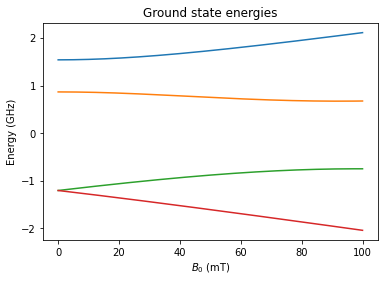

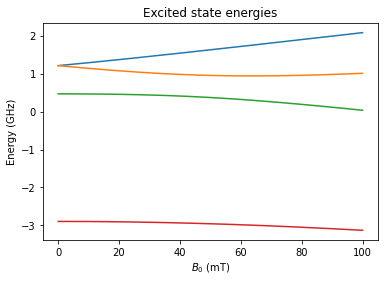

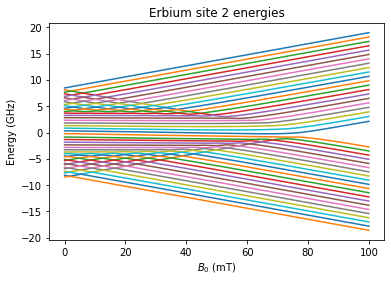

In [197]:
plt.plot(B0*1E3,np.squeeze(-1*FreqG[0,0,:,:]))
plt.title("Ground state energies")
plt.xlabel(r"$B_{0}$ (mT)")
plt.ylabel("Energy (GHz)")
plt.show()
plt.close()
plt.plot(B0*1E3,np.squeeze(-1*FreqE[0,0,:,:]))
plt.title("Excited state energies")
plt.xlabel(r"$B_{0}$ (mT)")
plt.ylabel("Energy (GHz)")
plt.show()
plt.close()
plt.plot(B0*1E3,np.squeeze(-1*FreqEr[0,0,:,:]))
plt.title("Erbium site 2 energies")
plt.xlabel(r"$B_{0}$ (mT)")
plt.ylabel("Energy (GHz)")
#plt.savefig("erbium_Jevon.png")
plt.show()
plt.close()

[ 0.32729584  0.32729584  1.07198559  4.44058218 -0.34695629 -0.34695629
  0.39773346  3.76633005 -2.41915782 -2.41915782 -1.67446807  1.69412852
 -2.41915782 -2.41915782 -1.67446807  1.69412852]


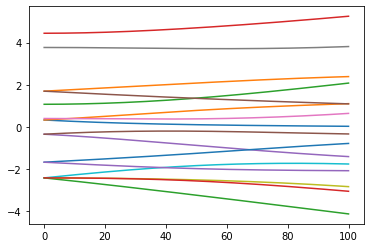

In [198]:
freq_def = spin.eachElemFunc(FreqE[0,0,:,:],FreqG[0,0,:,:],ax=1)
print(freq_def[0,:])
plt.plot(B0*1E3,np.squeeze(freq_def))
plt.show()
plt.close()